## 1. LLEGIR IMATGE I EXAMINAR INTENSITATS DEL PIXEL 

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
def imread_raw(filename, nrow, ncol):
 ## Llegeix una imatge RAW en escla de grisos
 ## filename--->nom de la imatge
 ## nrow--->nombre de files de la imatge
 ## ncol--->nombre de columnes de la imatge

 ## np.fromfile llegeix el file desitjat (filename)
 ## amb el tipus de data indicat (unit8) i el nombre total d'elements (nrow * ncol)   
    data = np.fromfile(filename, dtype=np.uint8, count=nrow * ncol)
 ## retorna una matriu NumPy unit8 unidimensiona amb (nrow x ncol) elements
 ## Creem la imatge fent una matriu 2D (nrow x ncol)
    img = data.reshape((nrow, ncol))

    return img

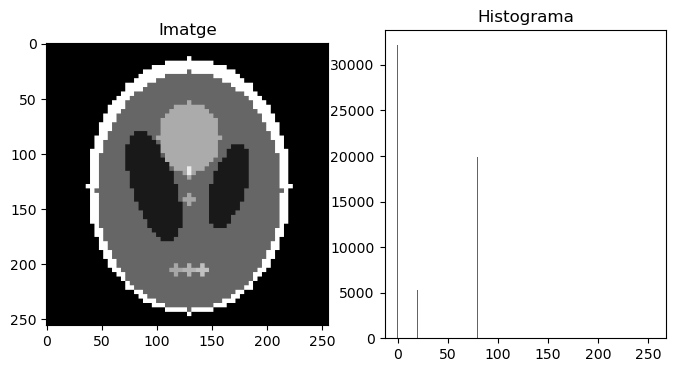

In [47]:
import cv2
import matplotlib.pyplot as plt
img = imread_raw("BRAIN.RAW",256,256)
hist = cv2.calcHist([img],[0],None,[256],[0,256])

plt.figure(figsize = (8,4))
plt.subplot(1,2,1)
plt.title("Imatge")
plt.imshow(img,cmap="gray")
plt.subplot(1,2,2)
plt.title("Histograma")
plt.bar(np.arange(0,256,1),hist.flatten())
plt.show()

### Estudiar el perfil d'intensitats

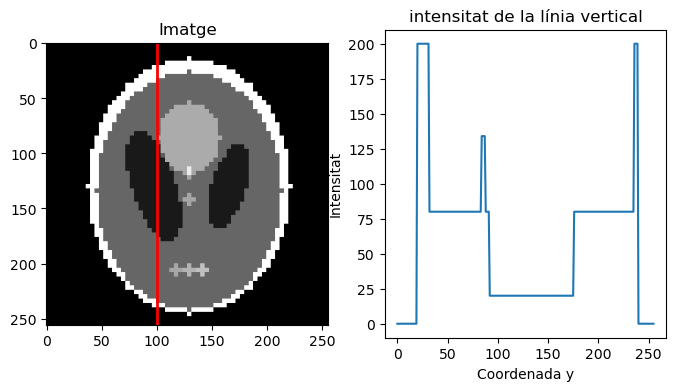

In [48]:
xi = 100

plt.figure(figsize = (8,4))
plt.subplot(1,2,1)
plt.title("Imatge")
plt.imshow(img,cmap="gray")
plt.axvline(x=xi, color='r', linewidth=2)
#dibuixa una linia vertical que estudiarem
plt.subplot(1, 2, 2)
plt.plot(img[:, xi])
#cada valor en l'eix vertical de pixel per la columna xi
plt.title('intensitat de la línia vertical')
plt.xlabel('Coordenada y')
plt.ylabel('Intensitat')
plt.show()



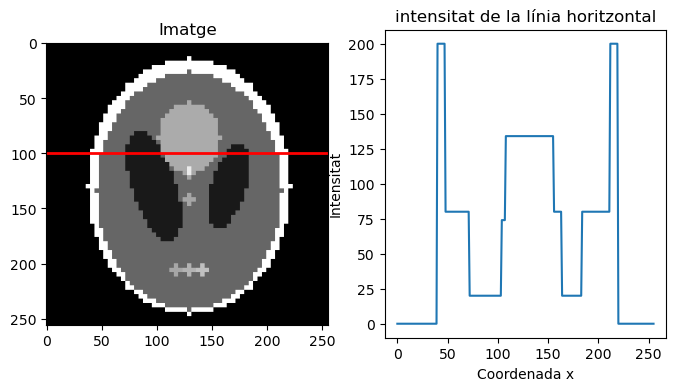

In [49]:
#el mateix per l'eix y

yi = 100

plt.figure(figsize = (8,4))
plt.subplot(1,2,1)
plt.title("Imatge")
plt.imshow(img,cmap="gray")
plt.axhline(y=yi, color='r', linewidth=2)
#dibuixa una linia vertical que estudiarem
plt.subplot(1, 2, 2)
plt.plot(img[yi, :])
#cada valor en l'eix vertical de pixel per la columna xi
plt.title('intensitat de la línia horitzontal')
plt.xlabel('Coordenada x')
plt.ylabel('Intensitat')
plt.show()

## ACTIVITAT 2.1. Trobeu la mida de les dues elipses negres en nombre de píxels.

In [50]:
#elipse esquerra
#veient la linia de perfil juntament amb el plot, veiem que quan la linia passa per sobre de les elipses aquesta pren un valor de pixel al voltant de 25
#fent print de l'array img[:,100] veiem que és el valor 20
count = 0
for i in range(0,126): 
    for j in img[:,i]:
        if j == 20:
            count+=1
print(f"Tamany elipse esquerra {count} pixels")

Tamany elipse esquerra 3296 pixels


In [51]:
#elipse esquerra
count = 0
for i in range(125,256): 
    for j in img[:,i]:
        if j == 20:
            count+=1
print(f"Tamany elipse dreta {count} pixels")

Tamany elipse dreta 1968 pixels


## 2. EQUALITZACIO 

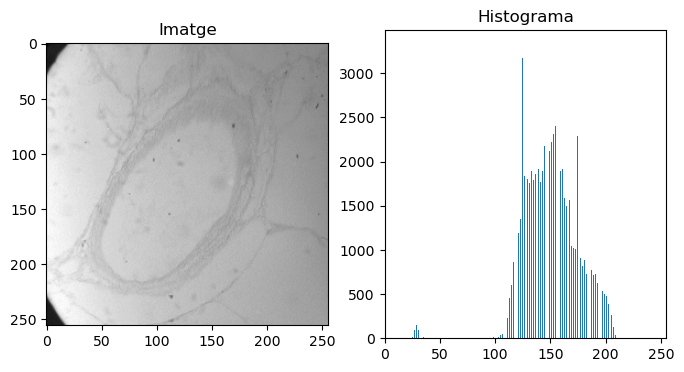

In [52]:
img = imread_raw("ART1BIO.raw",256,256)

hist = cv2.calcHist([img],[0],None,[256],[0,256])

plt.figure(figsize = (8,4))
plt.subplot(1,2,1)
plt.title("Imatge")
plt.imshow(img,cmap="gray")
plt.subplot(1,2,2)
plt.title("Histograma")
plt.bar(np.arange(0,256,1),hist.flatten())
plt.axis([0, 255, 0, hist.max() * 1.1])  # fixem que el maxim de l'histograma marqui l'escala del gràfic
plt.show()

### EXEMPLE 1: Equalitzador per defecte

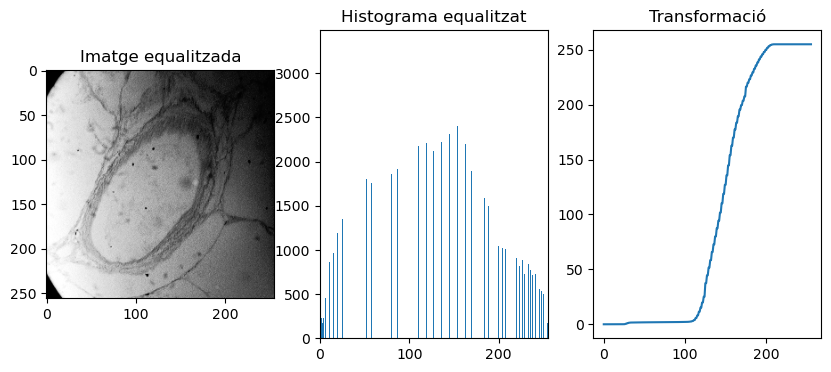

In [53]:
import math
N = 256

#imatge equalitzada amb el seu histograma
equ = cv2.equalizeHist(img)
histeq = cv2.calcHist([equ],[0],None,[256],[0,256])

#Transformació feta per equalitzar la imatge
#Python no te una funció automàtica així que ho fem manual

prob = hist/sum(hist)  
cumprob = np.cumsum(prob)
Transformation = cumprob

plt.figure(figsize = (10,4))
plt.subplot(1,3,1)
plt.title("Imatge equalitzada")
plt.imshow(equ,cmap="gray")
plt.subplot(1,3,2)
plt.title("Histograma equalitzat")
plt.bar(np.arange(0,256,1),histeq.flatten())
plt.axis([0, 255, 0, histeq.max() * 1.1]) 
plt.subplot(1,3,3)
plt.title("Transformació")
plt.plot(Transformation*255)
plt.show()

### EXAMPLE 2: Podem customitzar l'equalitzador

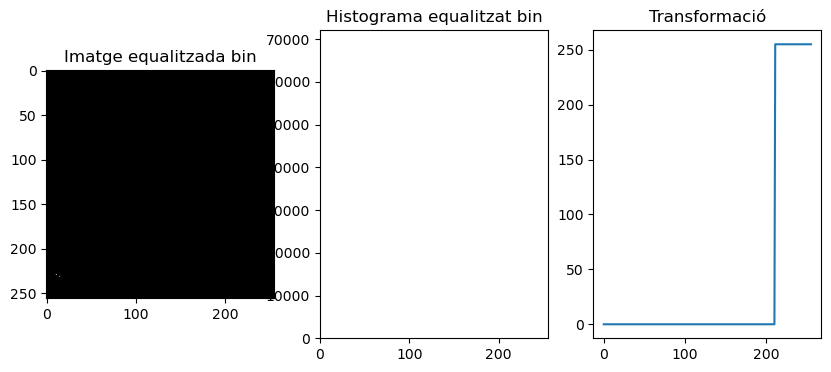

In [54]:
#Python no te una funció per personalitzar l'equalització, la farem manual.
def custom_eq(img,target):
    #Histograma original amb la probabilitat acumulada
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    prob = hist/sum(hist)  
    cumprob = np.cumsum(prob) 
    #Target
    target = np.array(target, dtype=np.float32)
    target = target/target.sum()
    target_cumprob = np.cumsum(target)
    #fer la transformació (mapa de valors)
    #amb aquesta funció np.interp(a,b,c) estem dient "troba, per cada valor de a, el corresponent interpolant entre b i c"
    transf = np.interp(cumprob,target_cumprob,np.arange(len(target)))
    #np.clip(porta els numeros mes petits que 0 a 0 i els mes grans que 255 a 255
    transf = np.clip(transf, 0, 255).astype(np.uint8)
    
    img = transf[img]
    return img,transf
    
target = [1,1] #binaritzar la imatge, histograma desitjat amb dos nivells iguals
[equ, transformation] = custom_eq(img,target)
histeq = cv2.calcHist([equ],[0],None,[256],[0,256])


plt.figure(figsize = (10,4))
plt.subplot(1,3,1)
plt.title("Imatge equalitzada bin")
plt.imshow(equ,cmap="gray")
plt.subplot(1,3,2)
plt.title("Histograma equalitzat bin")
plt.bar(np.arange(0,256,1),histeq.flatten())
plt.axis([0, 255, 0, histeq.max() * 1.1]) 
plt.subplot(1,3,3)
plt.title("Transformació")
plt.plot(transformation*255)
plt.show()

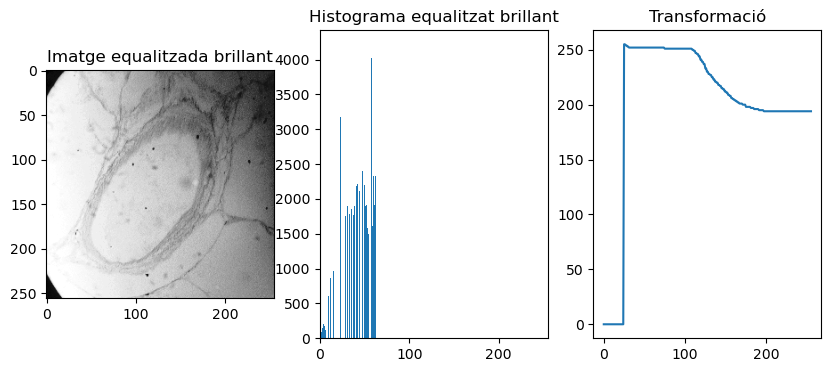

In [55]:
target = np.arange(64) #Resaltem el pixels brillants
[equ, transformation] = custom_eq(img,target)
histeq = cv2.calcHist([equ],[0],None,[256],[0,256])


plt.figure(figsize = (10,4))
plt.subplot(1,3,1)
plt.title("Imatge equalitzada brillant")
plt.imshow(equ,cmap="gray")
plt.subplot(1,3,2)
plt.title("Histograma equalitzat brillant")
plt.bar(np.arange(0,256,1),histeq.flatten())
plt.axis([0, 255, 0, histeq.max() * 1.1]) 
plt.subplot(1,3,3)
plt.title("Transformació")
plt.plot(transformation*255)
plt.show()


## ACTIVITAT 2.2. Proveu diferents opcions d'equalitzador i mostreu les imatges resultants, els histogrames i les transformacions

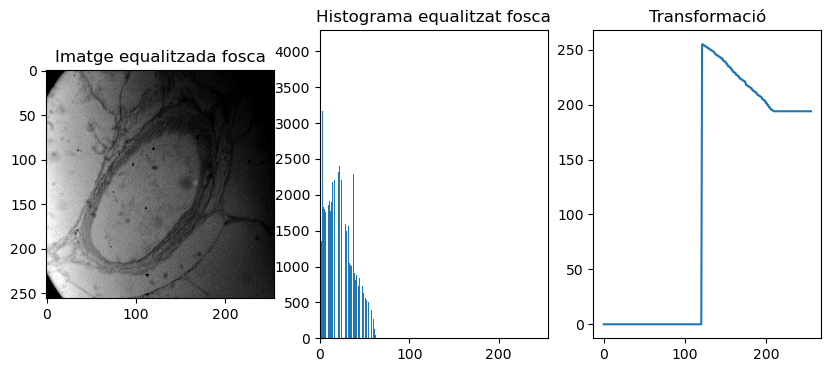

In [56]:
target = np.arange(64,-1,-1) #Resaltem el pixels foscos
[equ, transformation] = custom_eq(img,target)
histeq = cv2.calcHist([equ],[0],None,[256],[0,256])


plt.figure(figsize = (10,4))
plt.subplot(1,3,1)
plt.title("Imatge equalitzada fosca")
plt.imshow(equ,cmap="gray")
plt.subplot(1,3,2)
plt.title("Histograma equalitzat fosca")
plt.bar(np.arange(0,256,1),histeq.flatten())
plt.axis([0, 255, 0, histeq.max() * 1.1]) 
plt.subplot(1,3,3)
plt.title("Transformació")
plt.plot(transformation*255)
plt.show()

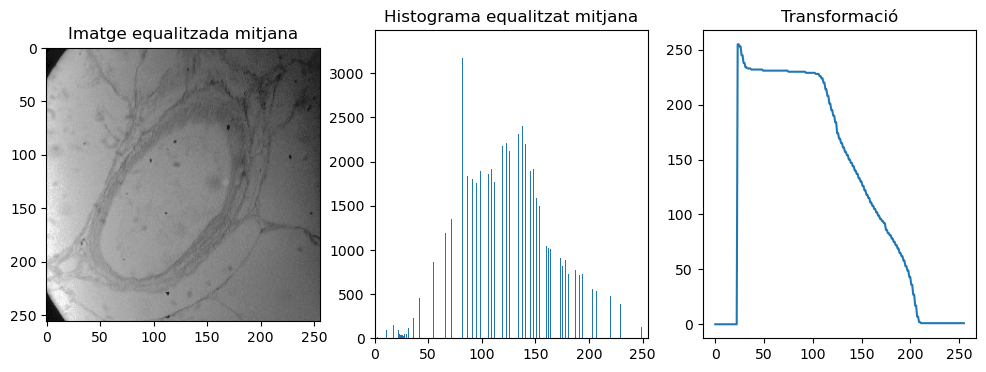

In [57]:
import scipy as sc

target = sc.stats.norm.pdf(np.linspace(-3, 3, 256)) #Resaltem el pixels mitjans
[equ, transformation] = custom_eq(img,target)
histeq = cv2.calcHist([equ],[0],None,[256],[0,256])


plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.title("Imatge equalitzada mitjana")
plt.imshow(equ,cmap="gray")
plt.subplot(1,3,2)
plt.title("Histograma equalitzat mitjana")
plt.bar(np.arange(0,256,1),histeq.flatten())
plt.axis([0, 255, 0, histeq.max() * 1.1]) 
plt.subplot(1,3,3)
plt.title("Transformació")
plt.plot(transformation*255)
plt.show()

## 3. Filtre de mediana
### ACTIVITAT 2.3. Afegiu soroll impulsional a la imatge i comproveu que aquest desapareix quan utilitzem el filtre de mediana (utilitzeu les comandes de la primera part de la pràctica)

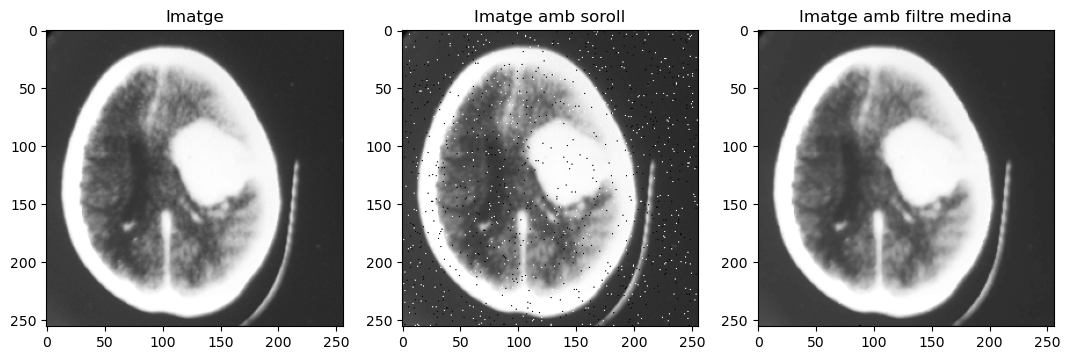

In [58]:
import skimage as sk

img = imread_raw("CT.raw",256,256)
img_noise = sk.util.random_noise(img,mode = "s&p",amount = 0.02)
img_median = sc.signal.medfilt2d(img_noise)
plt.figure(figsize = (13,4))

plt.subplot(1,3,1)
plt.title("Imatge")
plt.imshow(img,cmap="gray")
plt.subplot(1,3,2)
plt.title("Imatge amb soroll")
plt.imshow(img_noise,cmap="gray")
plt.subplot(1,3,3)
plt.title("Imatge amb filtre medina")
plt.imshow(img_median,cmap="gray")
plt.show()

## 4. FILTRE PASSA-BAIX 
### ACTIVITAT 2.4. Utilitzeu dues versions del filtre passa-baix (uniforme 3x3, i gaussià i observeu el resultat)

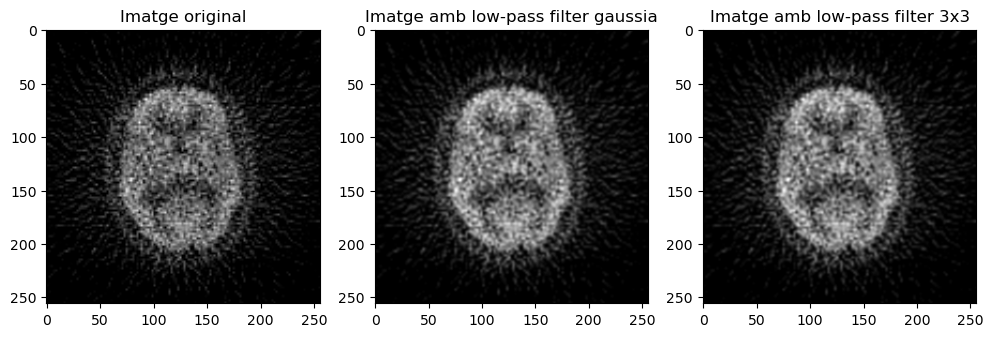

In [59]:
img = imread_raw("CEREBRO.raw",256,256)

img_float = img.astype(np.float64)
kernel = np.array([[1,2,1],[2,4,2],[1,2,1]])/16
kernel2 = np.ones((3,3),np.float64)/9
lpfimg = cv2.filter2D(img_float, -1, kernel)
lpfimg2 = cv2.filter2D(img_float, -1, kernel2)
lpfimg = lpfimg.astype(np.uint8)
lpfimg2 = lpfimg2.astype(np.uint8)

plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.title("Imatge original")
plt.imshow(img,cmap="gray")
plt.subplot(1,3,2)
plt.title("Imatge amb low-pass filter gaussia")
plt.imshow(lpfimg,cmap="gray")
plt.subplot(1,3,3)
plt.title("Imatge amb low-pass filter 3x3")
plt.imshow(lpfimg,cmap="gray")
plt.show()

## 5. FILTRE PASSA-ALT  
### ACTIVITAT 2.5. Utilitzeu varies versions del filtre passa-alt (laplaciana i direccionals)

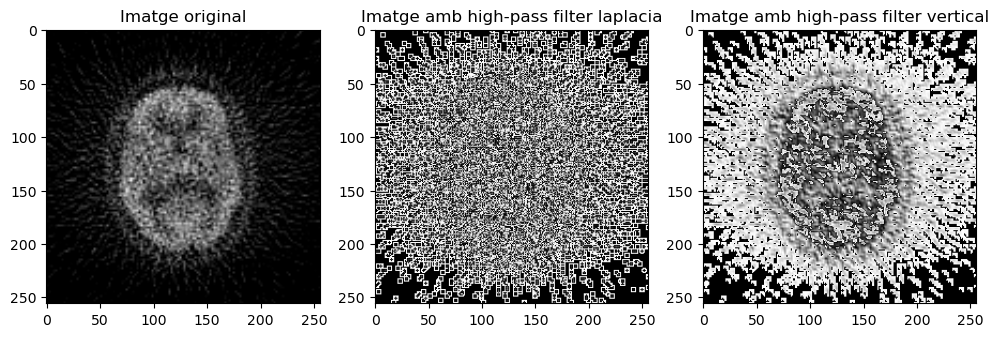

In [60]:
img_float = img.astype(np.float64)
kernel_lapl = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
kernel_ver = np.array([[-1,1,0],[-1,1,0],[-1,-1,-1]])
hpfimg_lapl = cv2.filter2D(img_float, -1, kernel_lapl)
hpfimg_ver = cv2.filter2D(img_float, -1, kernel_ver)
hpfimg_lapl = hpfimg_lapl.astype(np.uint8)
hpfimg_ver = hpfimg_ver.astype(np.uint8)

plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.title("Imatge original")
plt.imshow(img,cmap="gray")
plt.subplot(1,3,2)
plt.title("Imatge amb high-pass filter laplacia")
plt.imshow(hpfimg_lapl,cmap="gray")
plt.subplot(1,3,3)
plt.title("Imatge amb high-pass filter vertical")
plt.imshow(hpfimg_ver,cmap="gray")
plt.show()


## 6. FFT

In [61]:
img = imread_raw("CEREBRO.raw",256,256)
[i,j] = np.meshgrid(np.arange(1,256,1),np.arange(1,256,1))

### EXAMPLE 1: Fourier Transform and Inverse Transform 

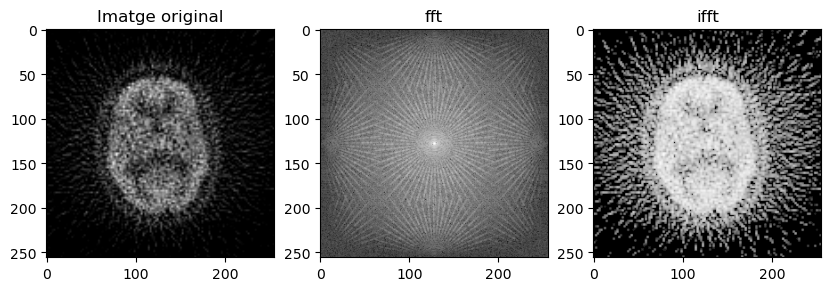

In [62]:
img_f = sc.fft.fft2(img)
img_f = sc.fft.fftshift(img_f)
img_reset = sc.fft.ifft2(img_f)

plt.figure(figsize = (10,4))
plt.subplot(1,3,1)
plt.title("Imatge original")
plt.imshow(img, cmap="gray")
plt.subplot(1,3,2)
plt.title("fft")
plt.imshow(np.log1p(np.abs(img_f)), cmap="gray")
plt.subplot(1,3,3)
plt.title("ifft")
plt.imshow(np.log1p(np.abs(img_reset)), cmap="gray")

plt.show()

### EXAMPLE 2: Low-Pass Spatial Filter using FT shifts 0-frequency harmonics to the center of image